### Initial statistical analysis

In [2]:
# Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import skill_metrics as sm
from scipy.stats import gaussian_kde
from matplotlib.ticker import FixedLocator
from matplotlib.colors import BoundaryNorm

In [3]:
# Paths and constants
DATA_DIR = "/home/rosquete/Documents/FRESH-CARE/data/fusion_evaluation/classic_evaluation/model_outputs"
OUTPUT_DIR = "/home/rosquete/Documents/FRESH-CARE/data/fusion_evaluation/classic_evaluation/results"

In [4]:
# Loading data
os.chdir(DATA_DIR)
files = {
    'ADT-0.25': 'ADT-0.25_interpolated.parquet',
    'ADT-SSS': 'ADT-SSS_interpolated.parquet',
    'ADT-SST': 'ADT-SST_interpolated.parquet',
    'OSCAR-geos': 'OSCAR-geos_interpolated.parquet'
}

all_data = []

for name, path in files.items():
    df = pd.read_parquet(path)

    # Rename dataset columns for consistency
    df = df.rename(columns={
        'vn': 'v_obs',
        've': 'u_obs'
    })

    # Model name
    df['model_name'] = name

    # Adding scalar speed columns
    df['speed_obs'] = np.sqrt(df['u_obs']**2 + df['v_obs']**2)
    df['speed_model'] = np.sqrt(df['u_model']**2 + df['v_model']**2)

    # Temporal columns
    df['time'] = pd.to_datetime(df['time'])
    
    all_data.append(df)


# Combine all dataframes into one 
master_df = pd.concat(all_data, ignore_index=True)

# Better memory usage
master_df['model_name'] = master_df['model_name'].astype('category')
master_df['id_sector'] = master_df['id_sector'].astype('category')

In [8]:
# Global metrics

def compute_global_metrics(df):
    """Compute global metrics for each model and variable."""

    df_clean = df.dropna(subset=['u_obs', 'v_obs', 'speed_obs']).copy()
    results = []

    # Loop through each model and variable to compute metrics
    for model in df_clean['model_name'].unique():
        m = df_clean[df_clean['model_name'] == model]

        for obs_col, mod_col, label in [('u_obs', 'u_model', 'U'), ('v_obs', 'v_model', 'V'), ('speed_obs', 'speed_model', 'Speed')]:
            obs, mod = m[obs_col], m[mod_col]
            error = mod - obs
            bias  = error.mean()
            rmse  = np.sqrt((error**2).mean())
            std_o = obs.std()
            std_m = mod.std()
            ss    = 1 - rmse**2 / (std_o**2 + bias**2 + (std_o - std_m)**2) if std_o > 0 else np.nan

            # Scalar metrics
            results.append({
                'Model':           model,
                'Variable':        label,
                'N':               len(obs.dropna()),
                'Mean_Obs [m/s]':  obs.mean(),
                'Mean_Mod [m/s]':  mod.mean(),
                'Bias [m/s]':      bias,
                'MAE [m/s]':       error.abs().mean(),
                'RMSE [m/s]':      rmse,
                'STD_Obs [m/s]':   std_o,
                'STD_Mod [m/s]':   std_m,
                'RMSE/STD [-]':    rmse / std_o if std_o > 0 else np.nan,
                'Corr [-]':        obs.corr(mod),
                'Skill Score [-]': ss,
                'MVE [m/s]':       np.nan,
            })

        valid = m[['u_obs', 'v_obs', 'u_model', 'v_model']].notna().all(axis=1)
        u_o, v_o = m.loc[valid, 'u_obs'].values,   m.loc[valid, 'v_obs'].values
        u_m, v_m = m.loc[valid, 'u_model'].values, m.loc[valid, 'v_model'].values

        # Vector metrics (RMSE and MVE)
        results.append({
            'Model':           model,
            'Variable':        'Vector (U+V)',
            'N':               valid.sum(),
            'Mean_Obs [m/s]':  np.nan,
            'Mean_Mod [m/s]':  np.nan,
            'Bias [m/s]':      np.nan,
            'MAE [m/s]':       np.nan,
            'RMSE [m/s]':      np.sqrt(((u_m - u_o)**2 + (v_m - v_o)**2).mean()),
            'STD_Obs [m/s]':   np.nan,
            'STD_Mod [m/s]':   np.nan,
            'RMSE/STD [-]':    np.nan,
            'Corr [-]':        np.nan,
            'Skill Score [-]': np.nan,
            'MVE [m/s]':       np.sqrt((u_m - u_o).mean()**2 + (v_m - v_o).mean()**2),
        })

    return pd.DataFrame(results)

final_report = compute_global_metrics(master_df)

# Display with styling
float_cols = [c for c in final_report.columns if final_report[c].dtype == float]

# Exclude means and standard deviations from best/worst signaling
metric_cols = [c for c in float_cols if c not in ['Mean_Obs [m/s]', 'Mean_Mod [m/s]', 'STD_Obs [m/s]', 'STD_Mod [m/s]']]

higher_is_better = {'Corr [-]', 'Skill Score [-]'}

def highlight_best_worst(col):
    styles = [''] * len(col)
    valid = col.dropna()
    if valid.empty:
        return styles

    # Bias: best is closest to zero, worst is farthest from zero
    if col.name == 'Bias [m/s]':
        best_idx = valid.abs().idxmin()
        worst_idx = valid.abs().idxmax()
    elif col.name in higher_is_better:
        best_idx = valid.idxmax()
        worst_idx = valid.idxmin()
    else:
        best_idx = valid.idxmin()
        worst_idx = valid.idxmax()

    i_best = col.index.get_loc(best_idx)
    i_worst = col.index.get_loc(worst_idx)
    styles[i_best] = 'background-color: #c6efce; color: #006100; font-weight: bold;'
    styles[i_worst] = 'background-color: #ffc7ce; color: #9c0006; font-weight: bold;'
    return styles

display(
    final_report.style
    .format({'N': '{:d}', **{c: '{:.4f}' for c in float_cols}})
    .set_caption('Global metrics — all models vs. drifters (velocities in m/s)')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold')]}])
    .apply(highlight_best_worst, subset=metric_cols, axis=0)
)

,Model,Variable,N,Mean_Obs [m/s],Mean_Mod [m/s],Bias [m/s],MAE [m/s],RMSE [m/s],STD_Obs [m/s],STD_Mod [m/s],RMSE/STD [-],Corr [-],Skill Score [-],MVE [m/s]
0,ADT-0.25,U,110286,-0.0036,-0.0095,-0.0079,0.0928,0.1253,0.1303,0.0788,0.9616,0.3290,0.2029,nan
1,ADT-0.25,V,110286,0.0032,0.0067,0.0034,0.0924,0.1258,0.1264,0.0779,0.9946,0.2913,0.1385,nan
2,ADT-0.25,Speed,110286,0.1417,0.0850,-0.0545,0.0861,0.1202,0.1137,0.0720,1.0578,0.3564,0.1798,nan
3,ADT-0.25,Vector (U+V),98113,nan,nan,nan,nan,0.1775,nan,nan,nan,nan,nan,0.0086
4,ADT-SSS,U,110286,-0.0036,-0.0061,-0.0043,0.0878,0.1203,0.1303,0.0533,0.9230,0.3421,0.3693,nan
5,ADT-SSS,V,110286,0.0032,0.0062,0.0031,0.0899,0.1231,0.1264,0.0647,0.9738,0.2754,0.2345,nan
6,ADT-SSS,Speed,110286,0.1417,0.0602,-0.0795,0.0975,0.1353,0.1137,0.0590,1.1904,0.2788,0.1762,nan
7,ADT-SSS,Vector (U+V),101147,nan,nan,nan,nan,0.1721,nan,nan,nan,nan,nan,0.0053
8,ADT-SST,U,110286,-0.0036,-0.0065,-0.0030,0.0915,0.1275,0.1303,0.0768,0.9783,0.3316,0.1812,nan
9,ADT-SST,V,110286,0.0032,0.0069,0.0036,0.0911,0.1271,0.1264,0.0773,1.0052,0.2991,0.1226,nan


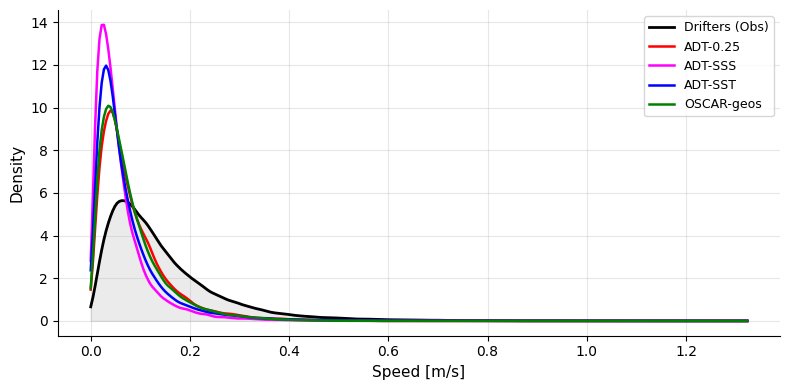

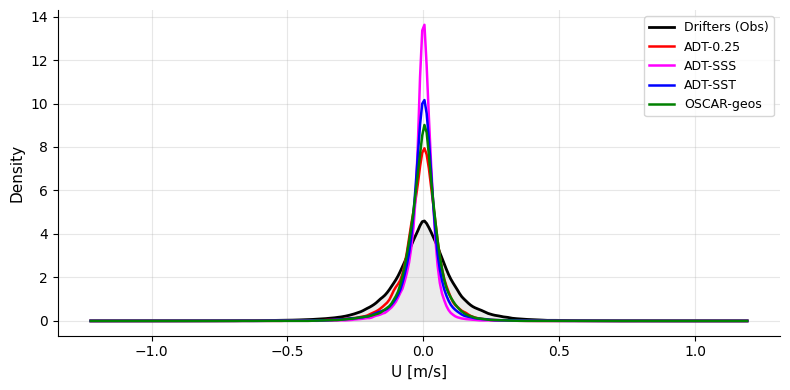

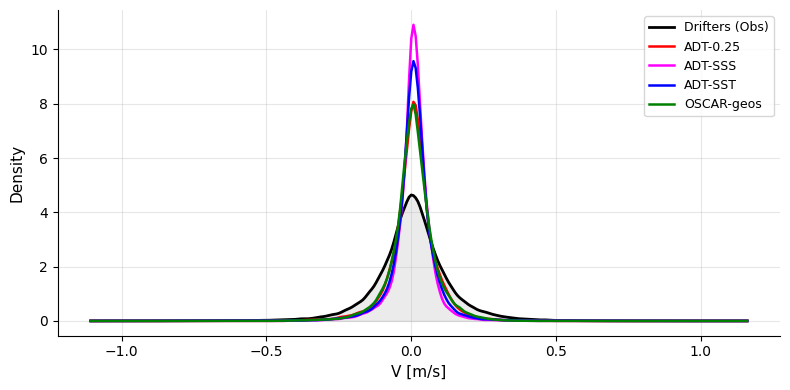

In [6]:
# Distribution plots — obs vs model per variable

def plot_distributions(df):
    """KDE distributions of obs vs model, one figure per variable."""
    df_clean = df.dropna(subset=["u_obs", "v_obs", "speed_obs"]).copy()
    variables = [
        ("speed_obs", "speed_model", "Speed [m/s]"),
        ("u_obs",     "u_model",     "U [m/s]"),
        ("v_obs",     "v_model",     "V [m/s]"),
    ]
    models = list(df_clean["model_name"].unique())
    colors = ["red", "magenta", "blue", "green"]  # Red, Magenta, Blue, Green

    for obs_col, mod_col, xlabel in variables:
        fig, ax = plt.subplots(figsize=(8, 4))

        obs_vals = df_clean[obs_col].dropna().values
        x_range  = np.linspace(obs_vals.min(), obs_vals.max(), 300)

        # Observations KDE (black)
        kde_obs = gaussian_kde(obs_vals)
        ax.plot(x_range, kde_obs(x_range), "k-", lw=2, label="Drifters (Obs)")
        ax.fill_between(x_range, kde_obs(x_range), alpha=0.08, color="k")

        # Model KDEs
        for i, model in enumerate(models):
            subset   = df_clean[df_clean["model_name"] == model]
            mod_vals = subset[mod_col].dropna().values
            if len(mod_vals) < 10:
                continue
            kde_mod = gaussian_kde(mod_vals)
            ax.plot(x_range, kde_mod(x_range), "-", color=colors[i % len(colors)],
                    lw=1.8, label=model)

        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("Density", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/distribution_{obs_col.replace('_obs', '')}.png", dpi=300)   
        plt.show()

plot_distributions(master_df)


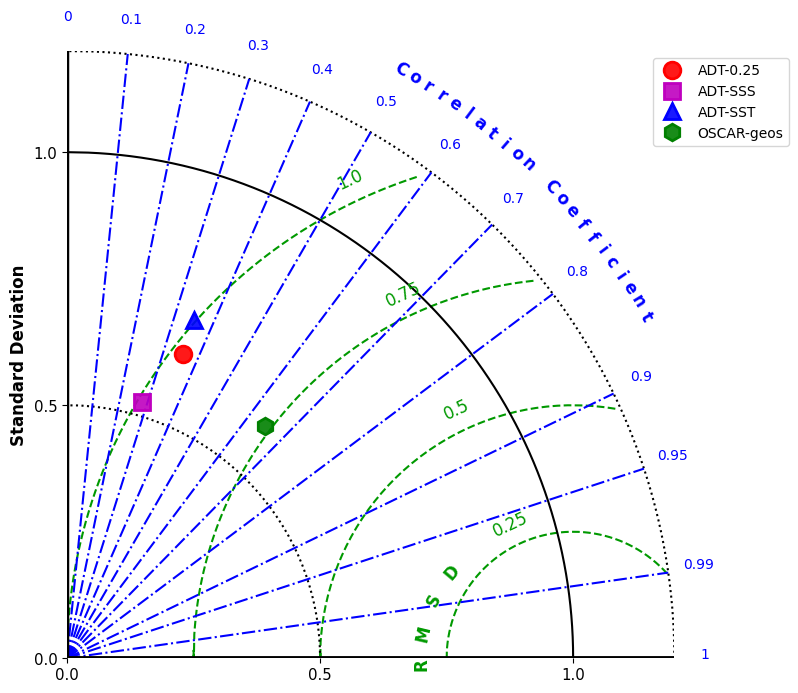

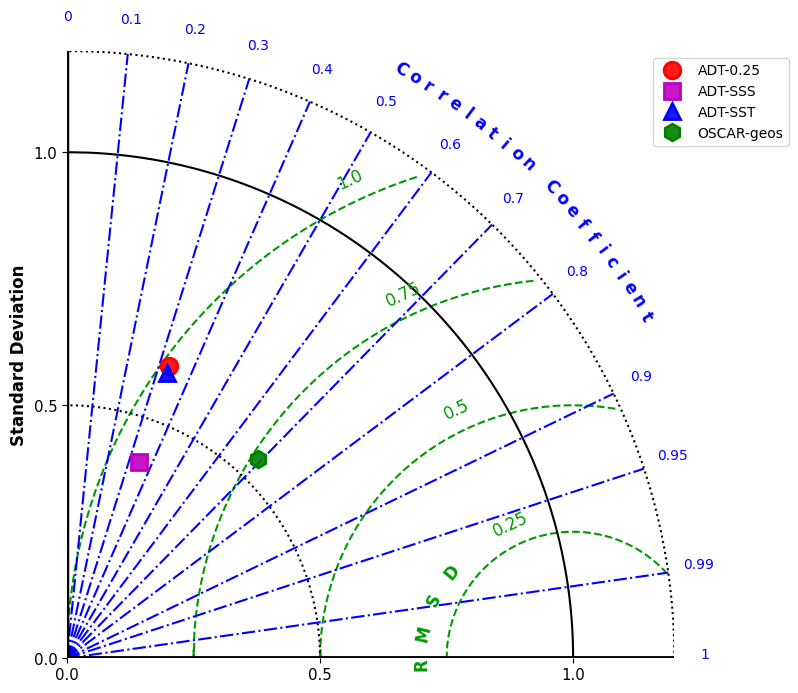

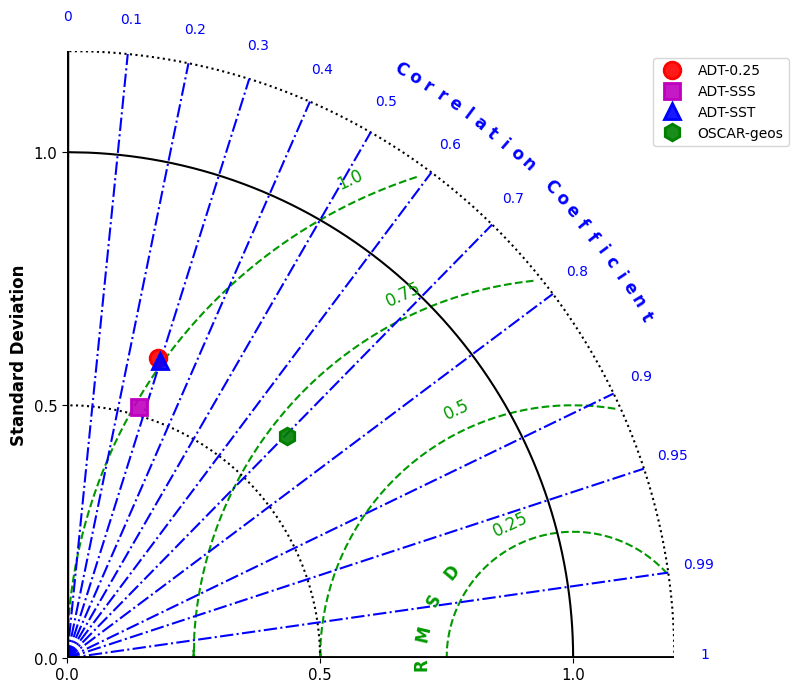

In [28]:
# Taylor diagrams 

def plot_taylor_arctic(df, variable_obs, variable_mod):
    """
    Taylor diagrams. Computes normalised statistics
    (STD, RMSE, Corr) per model vs drifters.
    """
    df_clean = df.dropna(subset=[variable_obs, variable_mod]).copy()
    models   = list(df_clean['model_name'].unique())

    # Reference STD from ALL observations
    std_ref = df_clean[variable_obs].std()

    # Build normalised statistics arrays: first entry = reference (Drifters)
    sdev  = [1.0]
    crmsd = [0.0]
    ccoef = [1.0]

    for model in models:
        subset = df_clean[df_clean['model_name'] == model]
        obs    = subset[variable_obs].values
        mod    = subset[variable_mod].values
        valid  = ~(np.isnan(obs) | np.isnan(mod))
        stats  = sm.taylor_statistics(mod[valid], obs[valid])
        sdev.append(stats['sdev'][1]  / std_ref)
        crmsd.append(stats['crmsd'][1] / std_ref)
        ccoef.append(stats['ccoef'][1])

    sdev  = np.array(sdev)
    crmsd = np.array(crmsd)
    ccoef = np.array(ccoef)

    fig = plt.figure(figsize=(8, 7))
    sm.taylor_diagram(sdev, crmsd, ccoef,
                      markerLabel      = ['Drifters (Ref)'] + models,
                      markerLegend     = 'on',
                      markerLabelColor = 'black',
                      markerSize       = 12,
                      default_colors   = ['r', 'm', 'b', 'g'],
                      default_markers  = ['o', 's', '^', 'h'],
                      tickRMS          = [0.25, 0.5, 0.75, 1.0],
                      tickRMSangle     = 115,
                      showlabelsRMS    = 'on',
                      titleRMS         = 'on',
                      titleSTD         = 'on',
                      titleCOR         = 'on',
                      tickSTD          = [0.5, 1.0],
                      axismax          = 1.2,
                      alpha            = 0.9)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/taylor_{variable_obs.replace('_obs', '')}.png", dpi=300)
    plt.show()

plot_taylor_arctic(master_df, 'speed_obs', 'speed_model')
plot_taylor_arctic(master_df, 'u_obs',     'u_model')
plot_taylor_arctic(master_df, 'v_obs',     'v_model')

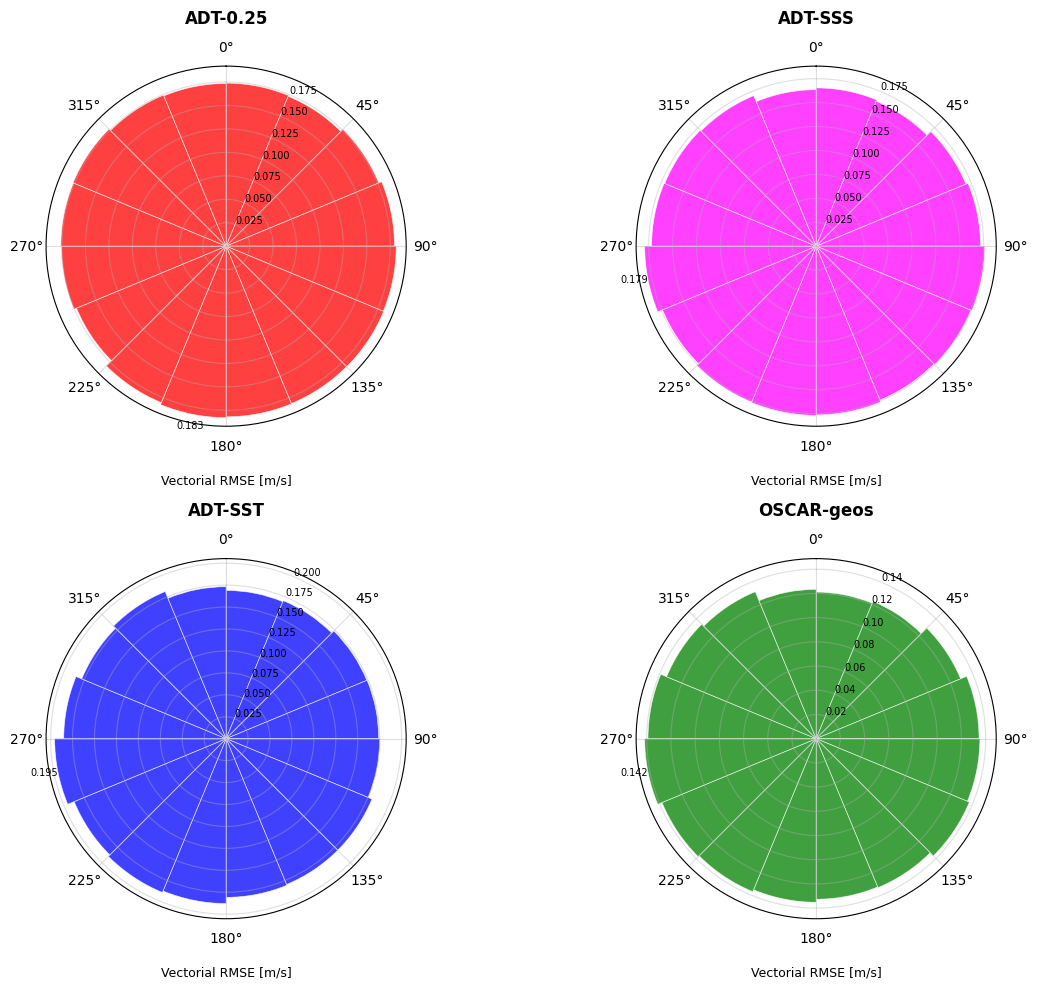

In [29]:
# Polar rose plots — vectorial RMSE by observed current direction

def plot_polar_roses(df, n_sectors=16):
    """
    One polar rose per model. Each sector shows the vectorial RMSE
    (sqrt of mean squared vector error) for observations whose direction
    falls in that angular bin. Direction is computed from the drifter (obs).
    """
    df_clean = df.dropna(subset=['u_obs', 'v_obs', 'u_model', 'v_model']).copy()

    # Observed direction: oceanographic convention (0° = East, CCW)
    # Meteorological-style for the rose: 0° = North, CW
    df_clean['dir_obs'] = np.degrees(np.arctan2(df_clean['u_obs'], df_clean['v_obs'])) % 360

    models  = list(df_clean['model_name'].unique())
    colors  = ['red', 'magenta', 'blue', 'green']

    # Sector edges and centres
    bin_edges   = np.linspace(0, 360, n_sectors + 1)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    width       = np.radians(360 / n_sectors)
    theta       = np.radians(bin_centres)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                             subplot_kw={'projection': 'polar'})
    axes = axes.flatten()

    for idx, model in enumerate(models):
        ax     = axes[idx]
        subset = df_clean[df_clean['model_name'] == model]

        rmse_per_sector = []
        counts          = []
        for i in range(n_sectors):
            lo, hi = bin_edges[i], bin_edges[i + 1]
            mask   = (subset['dir_obs'] >= lo) & (subset['dir_obs'] < hi)
            seg    = subset[mask]
            if len(seg) < 3:
                rmse_per_sector.append(0.0)
                counts.append(0)
            else:
                vec_err = np.sqrt((seg['u_model'] - seg['u_obs'])**2 +
                                  (seg['v_model'] - seg['v_obs'])**2)
                rmse_per_sector.append(np.sqrt((vec_err**2).mean()))
                counts.append(len(seg))

        rmse_arr = np.array(rmse_per_sector)

        # Polar bar: theta measured from North, clockwise → rotate + invert
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
        bars = ax.bar(theta, rmse_arr, width=width, bottom=0,
                      color=colors[idx % len(colors)], alpha=0.75, edgecolor='white', linewidth=0.5)

        ax.set_title(model, fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel('Vectorial RMSE [m/s]', labelpad=15, fontsize=9)
        ax.yaxis.set_tick_params(labelsize=7)
        ax.grid(True, alpha=0.4)

        # Annotate max sector
        max_idx = np.argmax(rmse_arr)
        ax.annotate(f'{rmse_arr[max_idx]:.3f}',
                    xy=(theta[max_idx], rmse_arr[max_idx]),
                    xytext=(theta[max_idx], rmse_arr[max_idx] * 1.08),
                    fontsize=7, color='black', ha='center')

    # fig.suptitle('Vectorial RMSE by observed current direction\n(direction from drifter, 0° = North)',
                #  fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/polar_rose_rmse.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_polar_roses(master_df, n_sectors=16)

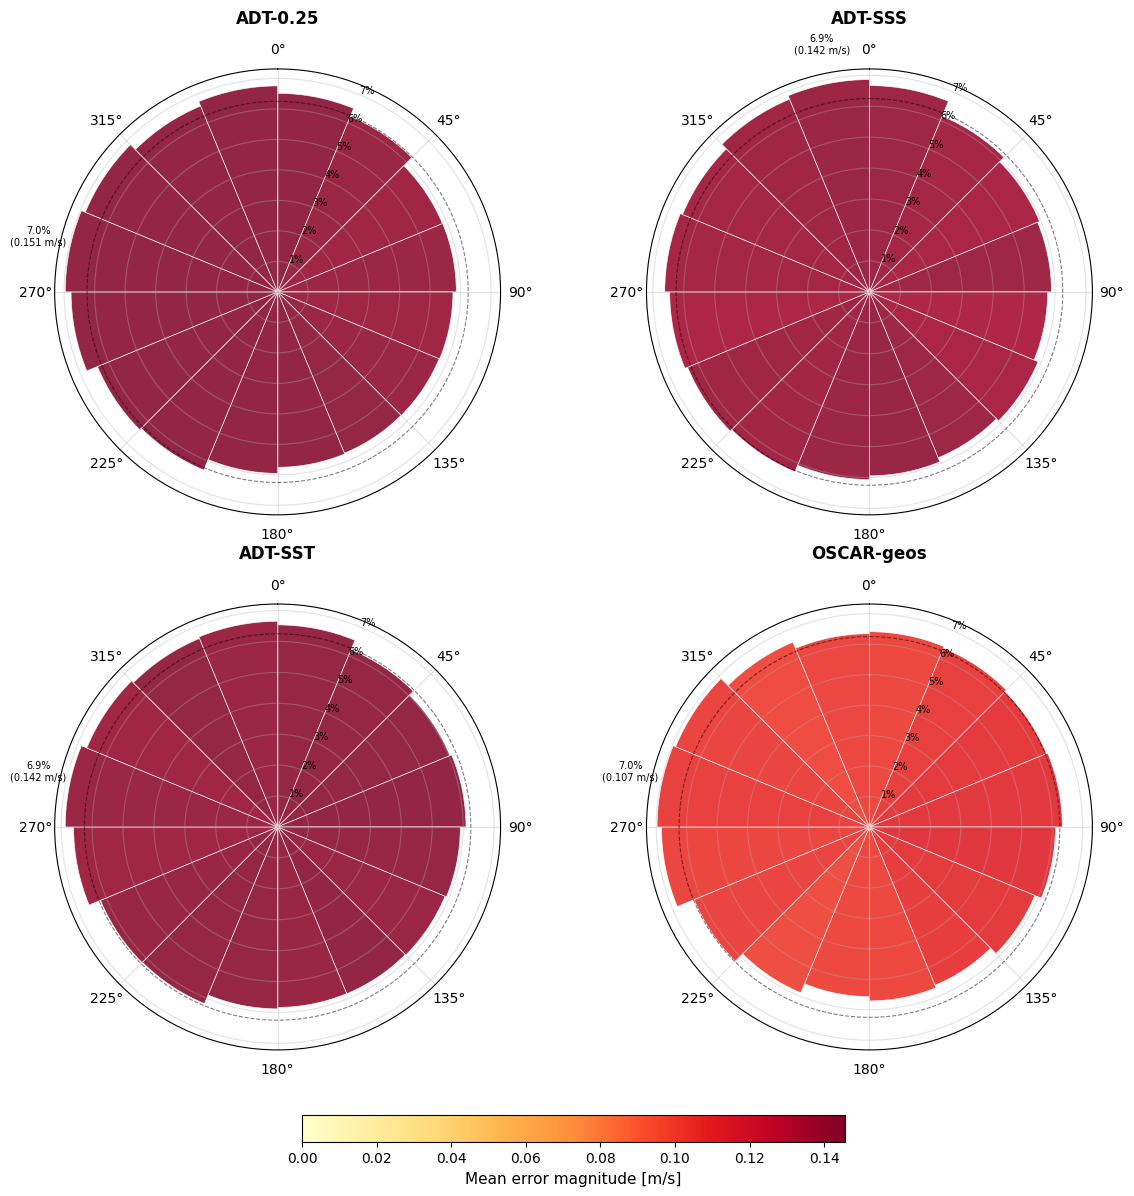

In [30]:
# Directional bias rose 

def plot_directional_bias_rose(df, n_sectors=16):
    """
    Shows the DIRECTION of the model error vector (mod - obs).
    - Bar length: frequency of errors pointing in that sector
    - Bar color:  mean magnitude of the error vector in that sector
    A dominant bar reveals a systematic directional bias.
    """
    df_clean = df.dropna(subset=['u_obs', 'v_obs', 'u_model', 'v_model']).copy()

    # Error vector direction 
    df_clean['err_u'] = df_clean['u_model'] - df_clean['u_obs']
    df_clean['err_v'] = df_clean['v_model'] - df_clean['v_obs']
    df_clean['err_mag'] = np.sqrt(df_clean['err_u']**2 + df_clean['err_v']**2)
    # Direction of error vector: 0° = North, clockwise
    df_clean['err_dir'] = np.degrees(np.arctan2(df_clean['err_u'], df_clean['err_v'])) % 360

    models = list(df_clean['model_name'].unique())
    
    bin_edges   = np.linspace(0, 360, n_sectors + 1)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    width       = np.radians(360 / n_sectors)
    theta       = np.radians(bin_centres)

    fig, axes = plt.subplots(2, 2, figsize=(14, 14),
                             subplot_kw={'projection': 'polar'})
    axes = axes.flatten()

    # Shared colormap normalization across all models
    global_max_mag = df_clean.groupby('model_name', observed=True)['err_mag'].mean().max()
    norm = plt.Normalize(vmin=0, vmax=global_max_mag)
    cmap = plt.cm.YlOrRd

    for idx, model in enumerate(models):
        ax     = axes[idx]
        subset = df_clean[df_clean['model_name'] == model]
        total  = len(subset)

        freq_per_sector = []
        mag_per_sector  = []

        for i in range(n_sectors):
            lo, hi = bin_edges[i], bin_edges[i + 1]
            mask = (subset['err_dir'] >= lo) & (subset['err_dir'] < hi)
            seg  = subset[mask]
            freq_per_sector.append(len(seg) / total if total > 0 else 0)
            mag_per_sector.append(seg['err_mag'].mean() if len(seg) > 0 else 0)

        freq_arr = np.array(freq_per_sector)
        mag_arr  = np.array(mag_per_sector)
        colors   = cmap(norm(mag_arr))

        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
        ax.bar(theta, freq_arr, width=width, bottom=0,
        color=cmap(norm(mag_arr)), alpha=0.85, edgecolor='white', linewidth=0.5)

        # Reference circle at uniform frequency (1/n_sectors)
        uniform = 1 / n_sectors
        ax.plot(np.linspace(0, 2*np.pi, 200), [uniform]*200,
                'k--', lw=0.8, alpha=0.5, label='Uniform')

        ax.set_title(model, fontsize=12, fontweight='bold', pad=14)
        yticks = [t for t in ax.get_yticks() if t > 0]
        ax.yaxis.set_major_locator(plt.FixedLocator(yticks))
        ax.set_yticklabels([f'{v:.0%}' for v in yticks], fontsize=7)
        ax.grid(True, alpha=0.35)

        # Annotate dominant direction
        max_idx = np.argmax(freq_arr)
        ax.annotate(f'{freq_arr[max_idx]:.1%}\n({mag_arr[max_idx]:.3f} m/s)',
                    xy=(theta[max_idx], freq_arr[max_idx]),
                    xytext=(theta[max_idx], freq_arr[max_idx] * 1.15),
                    fontsize=7, color='black', ha='center')

    # Colorbar
    sm_obj = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm_obj.set_array([])
    cbar = fig.colorbar(sm_obj, ax=axes, orientation='horizontal',
                        fraction=0.03, pad=0.06, shrink=0.5)
    cbar.set_label('Mean error magnitude [m/s]', fontsize=11)

    # fig.suptitle('Direction of model error vector\n(bar length = frequency, color = mean magnitude)',
                #  fontsize=13, fontweight='bold', y=1.01)

    plt.savefig(f'{OUTPUT_DIR}/directional_bias_rose.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_directional_bias_rose(master_df, n_sectors=16)

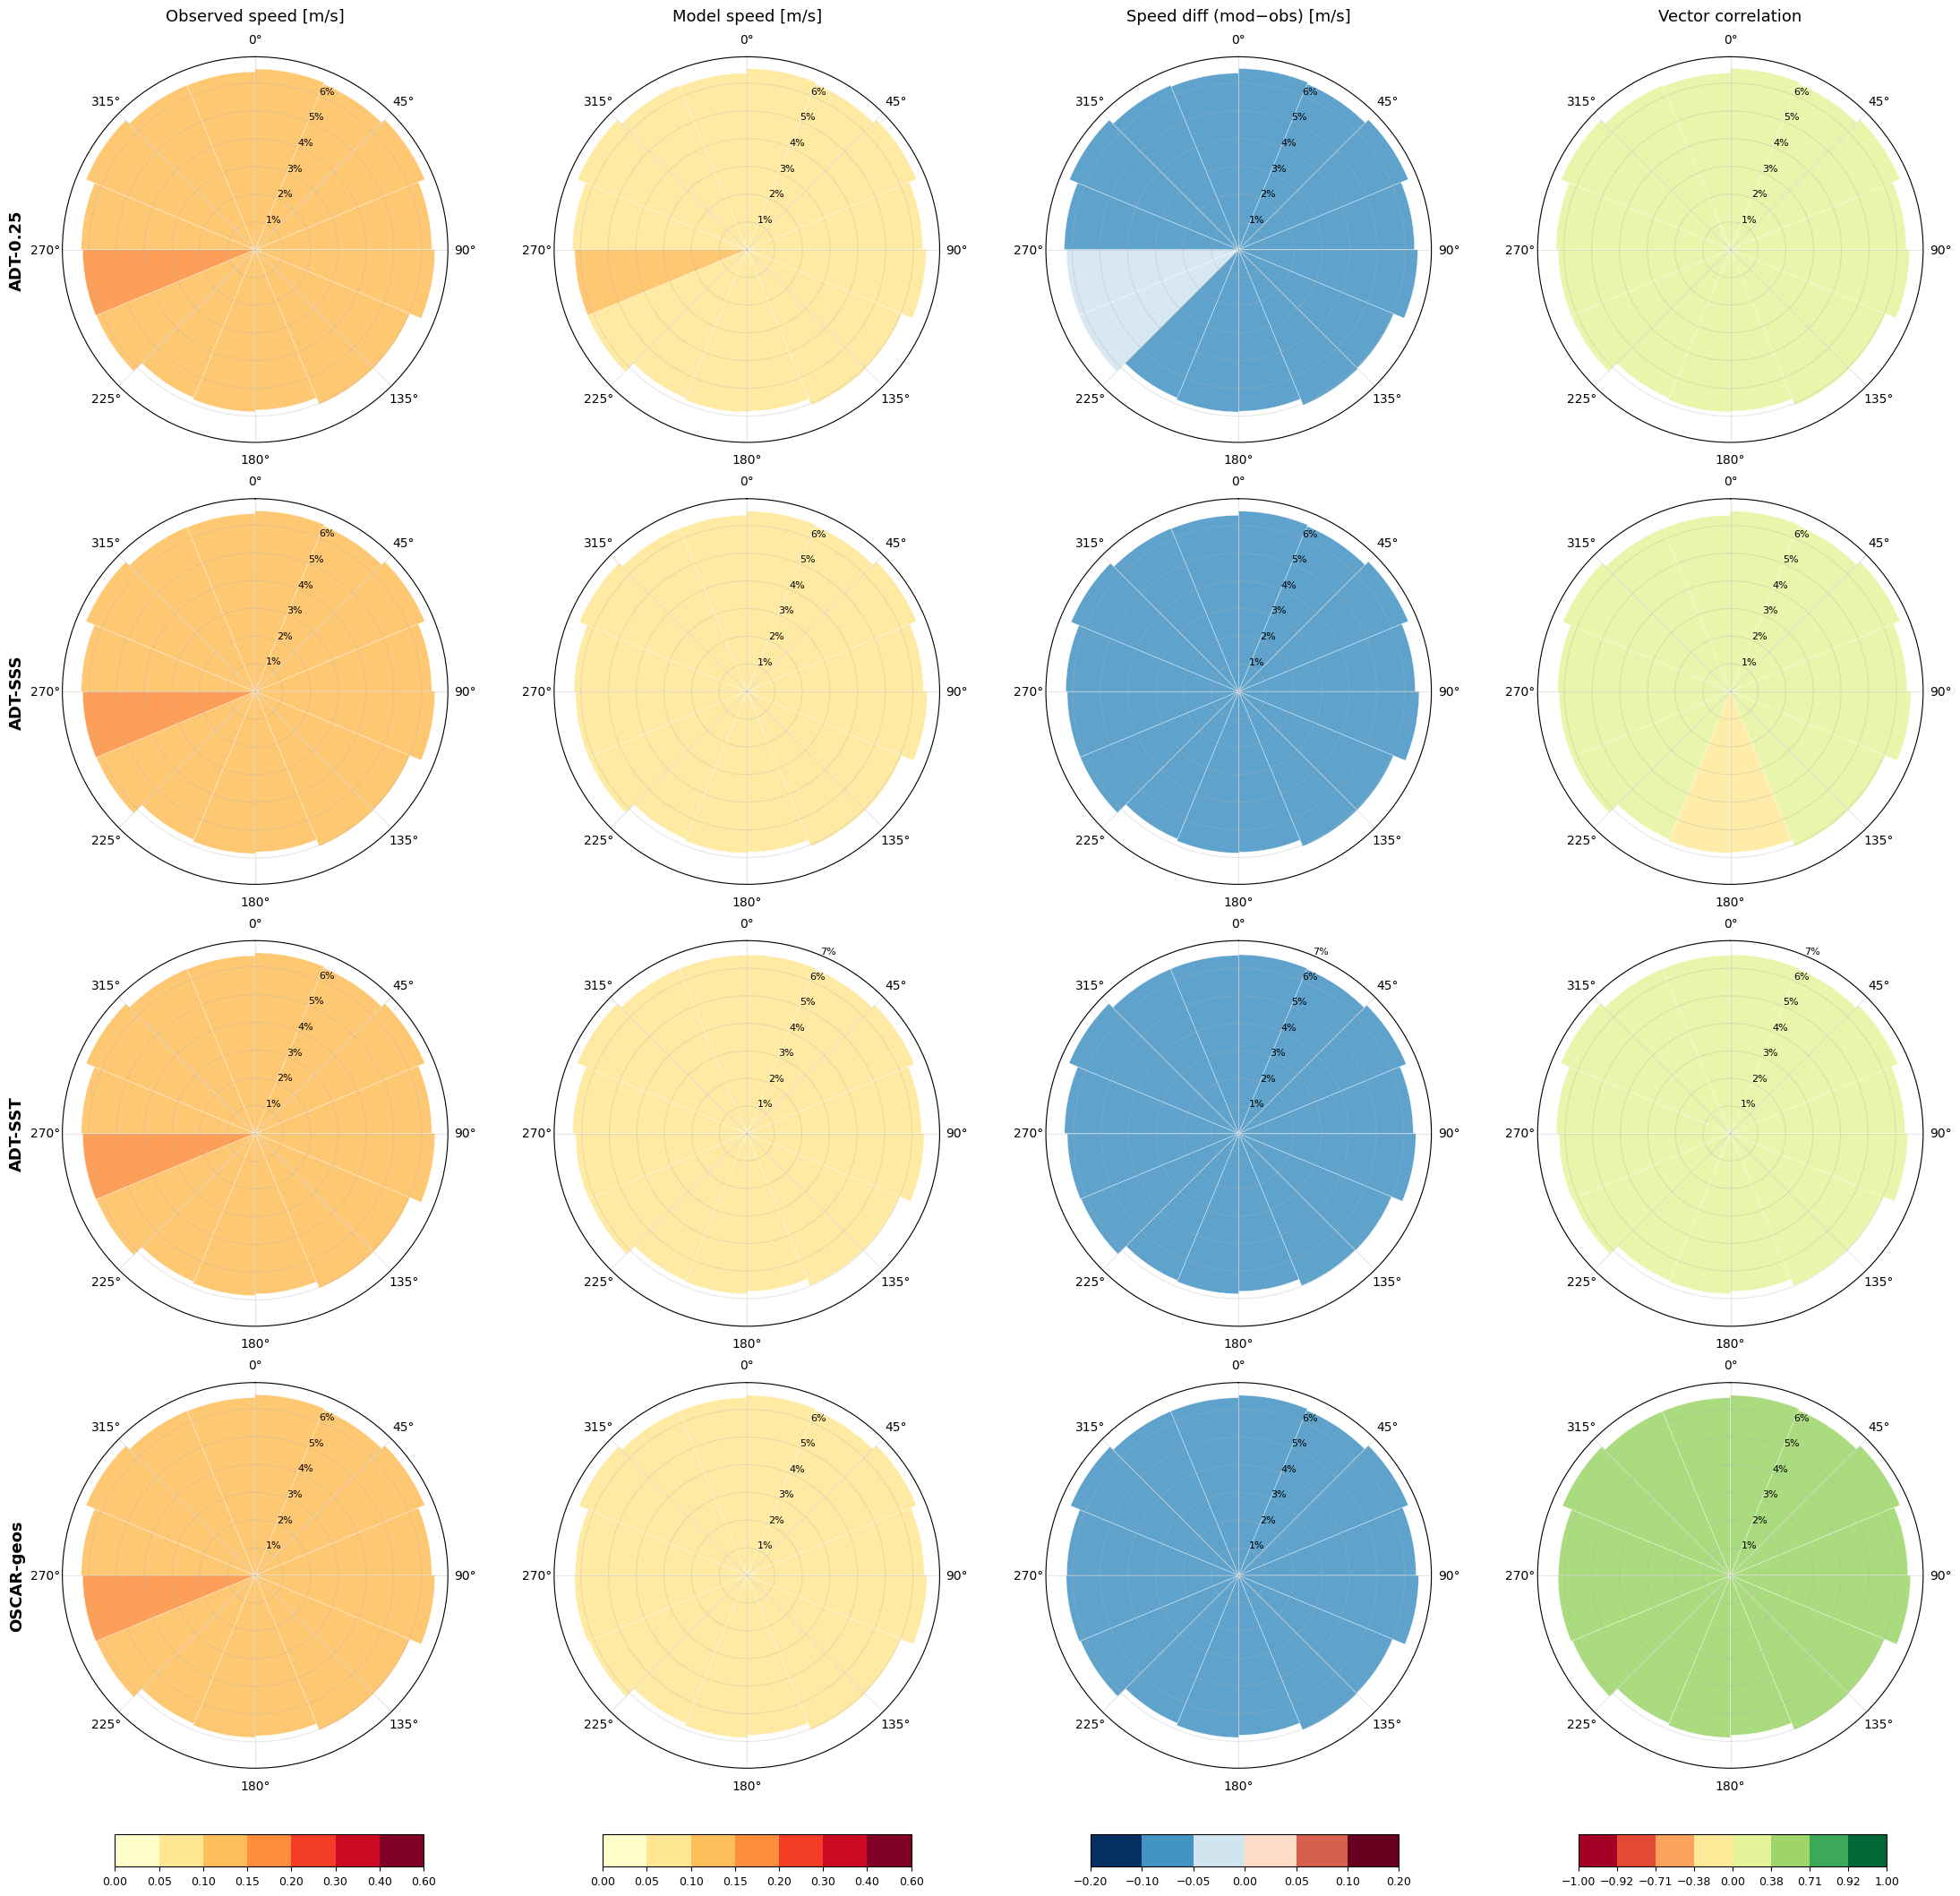

In [31]:
# Comprehensive rose plot — 4 columns x 4 models
# Col 1: Observed speed distribution by direction  (shared — same obs for every model)
# Col 2: Model speed distribution by direction
# Col 3: Speed difference (model - obs) by direction
# Col 4: Vector correlation by direction

def plot_comprehensive_rose(df, n_sectors=16):

    df_clean = df.dropna(subset=['u_obs', 'v_obs', 'u_model', 'v_model']).copy()
    df_clean['speed_obs']   = np.sqrt(df_clean['u_obs']**2   + df_clean['v_obs']**2)
    df_clean['speed_model'] = np.sqrt(df_clean['u_model']**2 + df_clean['v_model']**2)
    df_clean['speed_diff']  = df_clean['speed_model'] - df_clean['speed_obs']
    # Vector correlation per point: cos of angle between vectors
    dot   = df_clean['u_obs']*df_clean['u_model'] + df_clean['v_obs']*df_clean['v_model']
    mag_o = df_clean['speed_obs'].replace(0, np.nan)
    mag_m = df_clean['speed_model'].replace(0, np.nan)
    df_clean['vec_corr'] = dot / (mag_o * mag_m)
    # Direction from drifter: 0° = North, CW
    df_clean['dir_obs'] = np.degrees(np.arctan2(df_clean['u_obs'], df_clean['v_obs'])) % 360

    models      = list(df_clean['model_name'].unique())
    n_models    = len(models)
    bin_edges   = np.linspace(0, 360, n_sectors + 1)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    width       = np.radians(360 / n_sectors)
    theta       = np.radians(bin_centres)

    # Color bins
    speed_bins  = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.60]
    speed_cmap  = plt.cm.YlOrRd
    speed_norm  = BoundaryNorm(speed_bins, speed_cmap.N)

    diff_bins   = [-0.20, -0.10, -0.05, 0, 0.05, 0.10, 0.20]
    diff_cmap   = plt.cm.RdBu_r
    diff_norm   = BoundaryNorm(diff_bins, diff_cmap.N)

    corr_bins   = [-1.0, -0.92, -0.71, -0.38, 0.0, 0.38, 0.71, 0.92, 1.0]
    corr_cmap   = plt.cm.RdYlGn
    corr_norm   = BoundaryNorm(corr_bins, corr_cmap.N)

    col_meta = [
        ('speed_obs',   speed_cmap, speed_norm, speed_bins, 'Observed speed [m/s]'),
        ('speed_model', speed_cmap, speed_norm, speed_bins, 'Model speed [m/s]'),
        ('speed_diff',  diff_cmap,  diff_norm,  diff_bins,  'Speed diff (mod−obs) [m/s]'),
        ('vec_corr',    corr_cmap,  corr_norm,  corr_bins,  'Vector correlation'),
    ]

    # Figure and axes
    fig, axes = plt.subplots(
        n_models, 4,
        figsize=(22, 5 * n_models),
        subplot_kw={'projection': 'polar'},
        constrained_layout=True,
    )
    if n_models == 1:
        axes = axes[np.newaxis, :]

    # Roses
    for row, model in enumerate(models):
        subset = df_clean[df_clean['model_name'] == model]

        for col, (var, cmap, norm, _, title) in enumerate(col_meta):
            ax = axes[row, col]
            ax.set_theta_zero_location('N')
            ax.set_theta_direction(-1)

            # Col 0: use ALL observations
            data_src = df_clean if col == 0 else subset

            total = len(data_src)
            for i in range(n_sectors):
                lo, hi = bin_edges[i], bin_edges[i + 1]
                seg = data_src[(data_src['dir_obs'] >= lo) & (data_src['dir_obs'] < hi)]
                if len(seg) < 3:
                    continue
                pct      = 100.0 * len(seg) / total
                mean_val = seg[var].mean()
                color    = cmap(norm(mean_val))
                ax.bar(theta[i], pct, width=width, bottom=0,
                       color=color, alpha=0.85, edgecolor='white', linewidth=0.3)

            ax.set_title(title if row == 0 else '', fontsize=13, pad=10)
            ax.grid(True, alpha=0.3)
            yticks = [t for t in ax.get_yticks() if t > 0]
            ax.yaxis.set_major_locator(FixedLocator(yticks))
            ax.set_yticklabels([f'{v:.0f}%' for v in yticks], fontsize=8)

        # Model label on the left
        axes[row, 0].set_ylabel(model, fontsize=13, fontweight='bold', labelpad=30)

    # Colorbars
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    fig_w, fig_h = fig.get_figwidth() * fig.dpi, fig.get_figheight() * fig.dpi

    for col_idx, (_, cmap, norm, bins, _) in enumerate(col_meta):
        col_axs = [axes[r, col_idx] for r in range(n_models)]
        bboxes  = [ax.get_window_extent(renderer) for ax in col_axs]

        # Normalise to figure fraction
        x0 = min(b.x0 for b in bboxes) / fig_w
        x1 = max(b.x1 for b in bboxes) / fig_w
        y0 = min(b.y0 for b in bboxes) / fig_h

        cbar_left   = x0 + (x1 - x0) * 0.10   
        cbar_width  = (x1 - x0) * 0.80
        cbar_bottom = y0 - 0.055              
        cbar_height = 0.018

        cbar_ax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
        sm_cb   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm_cb.set_array([])
        cbar = fig.colorbar(sm_cb, cax=cbar_ax, orientation='horizontal')
        cbar.set_ticks(bins)
        cbar.ax.tick_params(labelsize=9)

    plt.savefig(f'{OUTPUT_DIR}/comprehensive_rose.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_comprehensive_rose(master_df, n_sectors=16)
